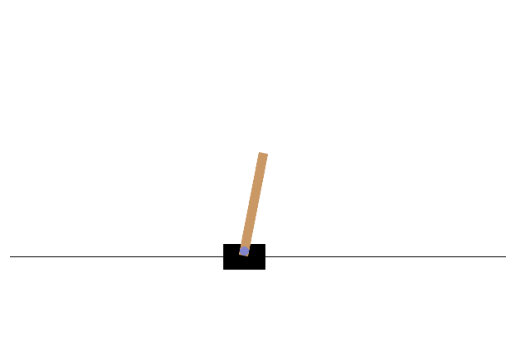

In [1]:
# Test the renderer
import gymnasium
from headless_renderer import headless_renderer

# Make gym env
env = gymnasium.make('CartPole-v1', render_mode = "rgb_array")
observation = env.reset()

# Create renderer
renderer = headless_renderer(env)

# Run the env
for t in range(1000):
    #Render to frames buffer
    renderer.update_display()
    action = env.action_space.sample()
    _, _, terminated, truncated, _ = env.step(action)
    done = terminated | truncated
    if done:
        break

env.close()

In [1]:
# Test the logger
from logger import logger

print("This should output if constants.logger is true:")
logger.log("Hello World!")

This should output if constants.logger is true:
Hello World!


[[47.620704650878906, 67.84210968017578, -319.5432434082031, 0, 0], [34.075273353842725, 77.55463487486738, 4.17403777327172, 0, 0]]
-29.961


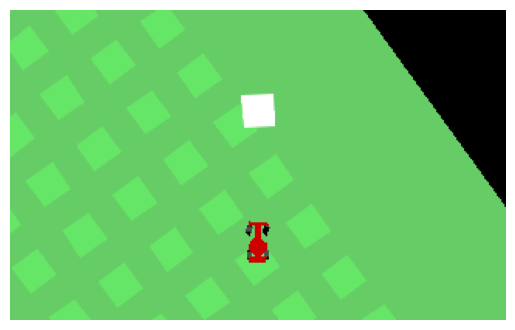

In [1]:
# Test rendering truck with given action, not an exhaustive test though, 
# might still have bugs, I suggest recover and run interactive tests.
# Known bugs: time calculation is not synchronized with real world, not sure how to fix yet
import gymnasium
import numpy as np
from headless_renderer import headless_renderer
from cargo_moving_truck_env import cargo_moving_truck_env
from constants import constants

# Register environment
gymnasium.register(id = "CargoMovingTruck-v0", entry_point = cargo_moving_truck_env)

# Make gym env
env = gymnasium.make('CargoMovingTruck-v0', render_mode = "rgb_array")

# Change/Delete random seed for fixed/random generations
observation = env.reset(seed = constants.RANDOM_SEED)

# Create renderer
renderer = headless_renderer(env)

# Run the env
for t in range(10000):
    #Render to frames buffer
    renderer.update_display()
    action = np.array([1, 0.01, 0])
    obs, reward, terminated, truncated, info = env.step(action)
    print(obs)
    print(reward)
    done = terminated | truncated
    if done:
        break

env.close()